In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import statsmodels.api as sm

In [2]:
df = pd.read_csv("../Diabetes.csv")

In [3]:
df

,Blood Sugar Level,Diabetes
0,190,No
1,240,Yes
2,300,Yes
3,160,No
4,200,Yes
5,269,Yes
6,129,No
7,141,No
8,220,No
9,337,Yes


In [4]:
df.describe()

,Blood Sugar Level
count,10.000000
mean,218.600000
std,68.550387
min,129.000000
25%,167.500000
50%,210.000000
75%,261.750000
max,337.000000


In [5]:
df["Sugar Level"] = df["Diabetes"].map(lambda x: 1 if x == "Yes" else 0)

In [6]:
df

,Blood Sugar Level,Diabetes,Sugar Level
0,190,No,0
1,240,Yes,1
2,300,Yes,1
3,160,No,0
4,200,Yes,1
5,269,Yes,1
6,129,No,0
7,141,No,0
8,220,No,0
9,337,Yes,1


In [7]:
df.describe()

,Blood Sugar Level,Sugar Level
count,10.000000,10.000000
mean,218.600000,0.500000
std,68.550387,0.527046
min,129.000000,0.000000
25%,167.500000,0.000000
50%,210.000000,0.500000
75%,261.750000,1.000000
max,337.000000,1.000000


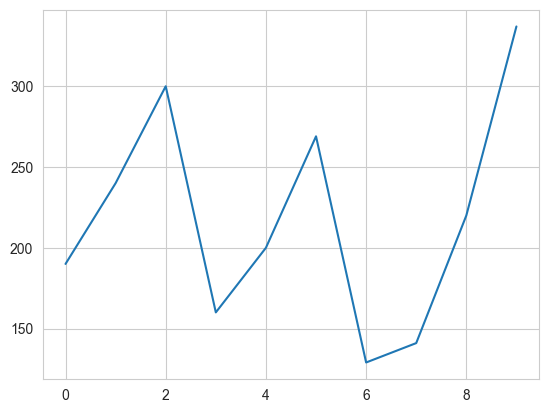

In [8]:
plt.plot(df["Blood Sugar Level"])

In [9]:
# Sigmoid Curve
# if we take B0=-15,B1=.015
# Plugging in to the data set
# probability_diabetes_y = 1/(1+np.e**(-B0+B1*x))
B0 = -15
B1 = 0.065
df["probability_diabetes"] = 1 / (1 + np.e ** (-(B0 + B1 * df["Blood Sugar Level"])))

In [10]:
df

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes
0,190,No,0,0.065989
1,240,Yes,1,0.645656
2,300,Yes,1,0.989013
3,160,No,0,0.009952
4,200,Yes,1,0.119203
5,269,Yes,1,0.923084
6,129,No,0,0.001338
7,141,No,0,0.002915
8,220,No,0,0.331812
9,337,Yes,1,0.998998


In [11]:
df.sort_values(by="probability_diabetes")

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes
6,129,No,0,0.001338
7,141,No,0,0.002915
3,160,No,0,0.009952
0,190,No,0,0.065989
4,200,Yes,1,0.119203
8,220,No,0,0.331812
1,240,Yes,1,0.645656
5,269,Yes,1,0.923084
2,300,Yes,1,0.989013
9,337,Yes,1,0.998998


<Axes: xlabel='Blood Sugar Level', ylabel='probability_diabetes'>

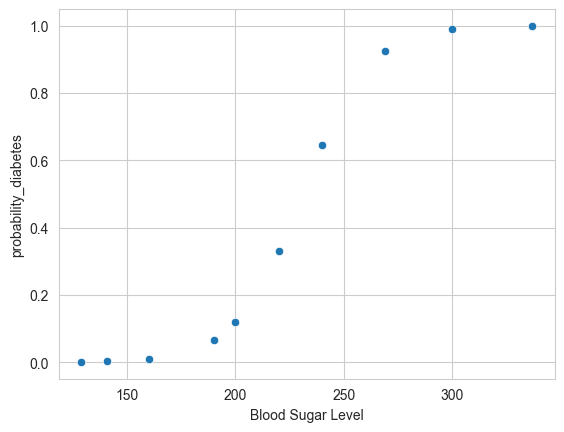

In [12]:
sns.scatterplot(y=df["probability_diabetes"], x=df["Blood Sugar Level"])

3.4313789332142752 0.6283925026760953 [[0.01660632 0.00080252]
 [0.00080252 0.00253648]]


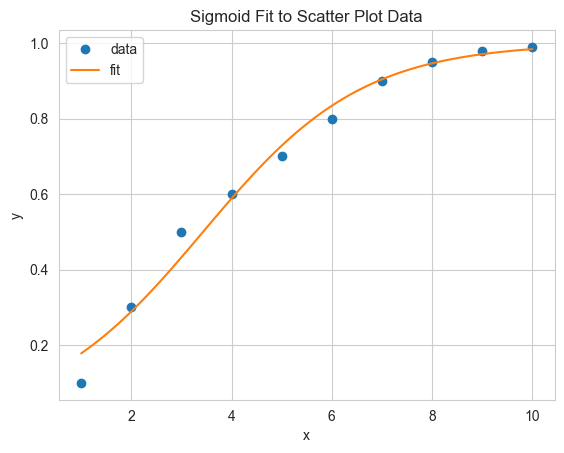

In [13]:
# Sample data
x_data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y_data = np.array([0.1, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98, 0.99])


# Sigmoid function
def sigmoid(x, x0, k):
    y = 1 / (1 + np.exp(-k * (x - x0)))
    return y


# Fit the sigmoid curve
popt, pcov = curve_fit(sigmoid, x_data, y_data, p0=[np.median(x_data), 1])

# Generate x values for the fitted curve
x_fit = np.linspace(min(x_data), max(x_data), 100)
# Calculate y values for the fitted curve
y_fit = sigmoid(x_fit, *popt)
print(*popt, pcov)
# Plot the scatter plot and the fitted sigmoid curve
plt.plot(x_data, y_data, "o", label="data")
plt.plot(x_fit, y_fit, "-", label="fit")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sigmoid Fit to Scatter Plot Data")
plt.show()

In [14]:
logm1 = sm.GLM(
    df["Sugar Level"],
    sm.add_constant(df["Blood Sugar Level"]),
    family=sm.families.Binomial(),
)
ols = logm1.fit()
print(ols.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Sugar Level   No. Observations:                   10
Model:                            GLM   Df Residuals:                        8
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2.5838
Date:                Tue, 20 May 2025   Deviance:                       5.1676
Time:                        02:05:10   Pearson chi2:                     4.32
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5809
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -13.5243      9.35

In [15]:
df["Odds"] = df["probability_diabetes"] / (1 - df["probability_diabetes"])

In [16]:
df

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes,Odds
0,190,No,0,0.065989,0.070651
1,240,Yes,1,0.645656,1.822119
2,300,Yes,1,0.989013,90.017131
3,160,No,0,0.009952,0.010052
4,200,Yes,1,0.119203,0.135335
5,269,Yes,1,0.923084,12.001120
6,129,No,0,0.001338,0.001340
7,141,No,0,0.002915,0.002923
8,220,No,0,0.331812,0.496585
9,337,Yes,1,0.998998,997.248513


In [17]:
df.sort_values(by="probability_diabetes")

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes,Odds
6,129,No,0,0.001338,0.001340
7,141,No,0,0.002915,0.002923
3,160,No,0,0.009952,0.010052
0,190,No,0,0.065989,0.070651
4,200,Yes,1,0.119203,0.135335
8,220,No,0,0.331812,0.496585
1,240,Yes,1,0.645656,1.822119
5,269,Yes,1,0.923084,12.001120
2,300,Yes,1,0.989013,90.017131
9,337,Yes,1,0.998998,997.248513


In [18]:
df["Log_Odds"] = np.log(df["Odds"])

In [19]:
df.sort_values(by="probability_diabetes")

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes,Odds,Log_Odds
6,129,No,0,0.001338,0.001340,-6.615
7,141,No,0,0.002915,0.002923,-5.835
3,160,No,0,0.009952,0.010052,-4.600
0,190,No,0,0.065989,0.070651,-2.650
4,200,Yes,1,0.119203,0.135335,-2.000
8,220,No,0,0.331812,0.496585,-0.700
1,240,Yes,1,0.645656,1.822119,0.600
5,269,Yes,1,0.923084,12.001120,2.485
2,300,Yes,1,0.989013,90.017131,4.500
9,337,Yes,1,0.998998,997.248513,6.905


<Axes: xlabel='Blood Sugar Level', ylabel='Log_Odds'>

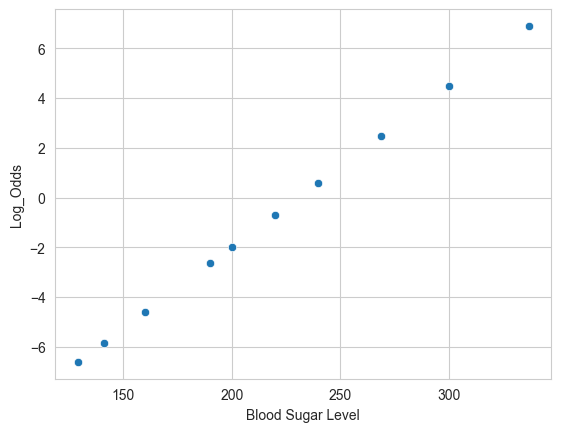

In [20]:
sns.scatterplot(df, x="Blood Sugar Level", y="Log_Odds")

In [21]:
df.to_excel("Diabetes.xlsx")

In [22]:
df["Blood Sugar Level"] += 11.5

In [23]:
df

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes,Odds,Log_Odds
0,201.5,No,0,0.065989,0.070651,-2.650
1,251.5,Yes,1,0.645656,1.822119,0.600
2,311.5,Yes,1,0.989013,90.017131,4.500
3,171.5,No,0,0.009952,0.010052,-4.600
4,211.5,Yes,1,0.119203,0.135335,-2.000
5,280.5,Yes,1,0.923084,12.001120,2.485
6,140.5,No,0,0.001338,0.001340,-6.615
7,152.5,No,0,0.002915,0.002923,-5.835
8,231.5,No,0,0.331812,0.496585,-0.700
9,348.5,Yes,1,0.998998,997.248513,6.905


In [28]:
def distribution1(df1, value, has_diabetes):
    nonlocal df

    df1["Sugar Level"] = df1["Diabetes"].map({"Yes": 1, "No": 0})
    df1["probability_diabetes"] = 1 / (1 + np.e ** (-(B0 + B1 * value)))
    df1["Odds"] = df1["probability_diabetes"] / (1 - df1["probability_diabetes"])
    df1["Log_Odds"] = np.log(df1["Odds"])
    # print(df1)

In [29]:
x = distribution1(243.5, "No")

In [30]:
df.merge(x, how="outer")

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes,Odds,Log_Odds
0,140.5,No,0,0.001338,0.001340,-6.6150
1,152.5,No,0,0.002915,0.002923,-5.8350
2,171.5,No,0,0.009952,0.010052,-4.6000
3,201.5,No,0,0.065989,0.070651,-2.6500
4,211.5,Yes,1,0.119203,0.135335,-2.0000
5,231.5,No,0,0.331812,0.496585,-0.7000
6,243.5,No,0,0.695826,2.287593,0.8275
7,251.5,Yes,1,0.645656,1.822119,0.6000
8,280.5,Yes,1,0.923084,12.001120,2.4850
9,311.5,Yes,1,0.989013,90.017131,4.5000


In [26]:
df

,Blood Sugar Level,Diabetes,Sugar Level,probability_diabetes,Odds,Log_Odds
0,201.5,No,0,0.065989,0.070651,-2.650
1,251.5,Yes,1,0.645656,1.822119,0.600
2,311.5,Yes,1,0.989013,90.017131,4.500
3,171.5,No,0,0.009952,0.010052,-4.600
4,211.5,Yes,1,0.119203,0.135335,-2.000
5,280.5,Yes,1,0.923084,12.001120,2.485
6,140.5,No,0,0.001338,0.001340,-6.615
7,152.5,No,0,0.002915,0.002923,-5.835
8,231.5,No,0,0.331812,0.496585,-0.700
9,348.5,Yes,1,0.998998,997.248513,6.905


In [39]:
dd = {"Blood Sugar Level": 10, "Diabetes": 0}

In [40]:
df

,Blood Sugar Level,Diabetes
Blood,10,0
Diabetes,10,0
